# NATS simulator — a small, explainable first version

**Steps 5 and 6: implementation, validation and experiments.** Open this notebook first and run the cells in order.
Keep `model.py`, `results.py` and `mm1.py` in the same folder. The executed outputs below
let you inspect the results without running anything immediately.

The simulator has a fixed fleet. Each aircraft repeats a journey between vertiports,
lands, unloads, charges and boards again. The outputs are tables, activity plots and queues.

**Read in this order:** settings → aircraft journey → results → scheduler → M/M/1.

## 1. Imports

If a package is missing, uncomment and run the installation line once, then restart the kernel.
No packages are installed automatically. After editing an imported `.py` file, restart the kernel
and run all cells so Python uses the new definitions. Python 3.9 or later is required.

In [1]:
# %pip install -r requirements.txt
from dataclasses import replace
from html import escape
import inspect
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from model import ScenarioConfig, Simulation, Aircraft
from results import summary, port_statistics, queue_trace, run_until_wait_limit
from mm1 import mm1

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

def table(headers, rows):
    heading = "".join(f"<th style='padding:8px'>{escape(str(x))}</th>" for x in headers)
    body = "".join("<tr>" + "".join(f"<td style='padding:8px'>{escape(str(x))}</td>"
                                 for x in row) + "</tr>" for row in rows)
    display(HTML(f"<table><thead><tr>{heading}</tr></thead><tbody>{body}</tbody></table>"))

## 2. Change the scenario here

`ScenarioConfig` is a container for settings. Each `Simulation(config)` creates an independent
experiment. Change settings **before** constructing a simulation; this version does not support
changing speeds or durations halfway through a flight. A configuration object avoids hidden,
mutable global settings and makes two scenarios easy to compare.

`headway_min=3` means that entry to cruise on the same directed route is separated by at least
three minutes. Actual departures can be further apart. With a common constant speed this also
preserves following separation along that route. A→B and B→A are independent corridors here.

In [2]:
config = ScenarioConfig(
    port_names=("A", "B"),
    fleet=8,
    stands_per_port=4,
    chargers_per_port=4,
    pads_per_port=1,
    routes_km={("A", "B"): 30, ("B", "A"): 30},
    speed_kmh=200,
    headway_min=3,
    charge_min=10,
    passengers=4,
    unload_min_per_passenger=1,
    board_min_per_passenger=1,
    taxi_out_min=1,
    takeoff_min=1,
    landing_min=1,
    taxi_in_min=1,
    horizon_min=720,
    time_scale_min=10,
    length_scale_km=30,
)
config.validate()
print("Configuration is valid.")

Configuration is valid.


### Which inputs have evidence?

This is a generic aircraft model informed by published assumptions and a manufacturer target;
it is not a validated digital model of a particular aircraft.

| Input | Value used | Provenance and interpretation |
|---|---:|---|
| Ports, stands, initial fleet, distance, headways | 2; 4 per port; 8; 30 km; 1/3/5 min | Agreed project scenarios. Headways are not regulatory minima. |
| Cruise speed | 200 km/h | Our scenario assumption, not a measured operational speed. |
| Takeoff / landing pad occupation | 1 min each | [NASA 2020, Table 1, printed p. 9](https://ntrs.nasa.gov/api/citations/20205001421/downloads/AIAA_Vertiport_Analysis_final_20200507.pdf?attachment=true): 60 s departure and arrival slots. These are research assumptions. |
| Taxi out / taxi in | 1 min each | The same NASA table assumes 120 s combined. Splitting it equally is our assumption. |
| Passenger unloading / loading | 1 min per passenger each | Same NASA table. At four passengers, 4 min for each operation. |
| Passenger count | 4 | [Archer Q3 2022 shareholder letter, p. 5](https://www.sec.gov/Archives/edgar/data/1824502/000162828022029481/q32022exhibit991.htm) describes Midnight with a pilot and four passengers. Pilot handling is omitted. |
| Charging | 10 min per mission | Same Archer letter, p. 5, footnote 3: an approximately 10-minute **target** after a 20-mile mission. Not a full recharge claim or measured repeated-mission performance. |

Unloading, charging and boarding are sequential. Charging stays fixed even when route distance
changes: this is an explicit simplification to replace with an energy model later. Ground transfers
have no separate capacity limit. The NASA paper itself used zero charging time; our charging
assumption comes from Archer instead. These references do not establish UK operating approval.

## 3. Dimensionless inside, familiar units outside

Choose reference scales $T_0=10$ minutes and $L_0=30$ km. Then

$$\hat t=\frac{t}{T_0},\qquad \hat d=\frac{d}{L_0},\qquad
V_0=\frac{L_0}{T_0}=3\text{ km/min}=180\text{ km/h},\qquad
\hat v=\frac{v}{V_0}.$$

Thus 720 minutes becomes **72 units of dimensionless time**, not 72 simulation steps.
SimPy advances directly between events. At 200 km/h, $\hat v=200/180=1.111\ldots$;
30 km gives $\hat d=1$, so $\hat t_{cruise}=1/1.111\ldots=0.9$, or **9 minutes**.
One-minute operations become 0.1; ten-minute charging becomes 1.
Counts such as four stands are already dimensionless.

For stochastic rates, $\hat\lambda=\lambda T_0$ and $\hat\mu=\mu T_0$.
Therefore $\rho=\hat\lambda/\hat\mu=\lambda/\mu$ is unchanged.
The automated tests change both reference scales and check that physical predictions stay the same.

In [3]:
reference_speed_kmh = 60 * config.length_scale_km / config.time_scale_min
table(["Quantity", "Physical value", "Dimensionless value"], [
    ["Run duration", f"{config.horizon_min} min", f"{config.time(config.horizon_min):.3f}"],
    ["Cruise speed", f"{config.speed_kmh} km/h", f"{config.speed_kmh/reference_speed_kmh:.3f}"],
    ["Charging duration", f"{config.charge_min} min", f"{config.time(config.charge_min):.3f}"],
    ["Following interval", f"{config.headway_min} min", f"{config.time(config.headway_min):.3f}"],
])

Quantity,Physical value,Dimensionless value
Run duration,720 min,72.000
Cruise speed,200 km/h,1.111
Charging duration,10 min,1.000
Following interval,3 min,0.300


## 4. The aircraft lifecycle — start reading the code here

`Aircraft.run()` below is the actual function from `model.py`. `self` means this particular
aircraft; `s` is its simulation and `c` its configuration. `activity()` records the state and
waits for a duration. `yield from` runs that small helper inside the current process.

The aircraft requests a flight plan while still on its stand. Once cleared it transfers to the pad,
takes off, cruises, lands and transfers to its destination stand. It then unloads, waits for a charger
if necessary, charges and boards. The same aircraft repeats; no new aircraft are generated.

An aircraft keeps its stand throughout unloading, charger waiting, charging, boarding and dispatch
waiting. Only the charging state consumes a charger. Every initial aircraft is charged and boarded.

In [4]:
print(inspect.getsource(Aircraft.run))

    def run(self):
        s, c = self.sim, self.sim.config
        while True:
            self.route = next(s.destinations[self.port])
            s.log.state(self.name, s.env.now, "dispatch_wait", self.port)
            plan = yield s.scheduler.request(self)
            yield from self.activity("taxi_out", c.time(c.taxi_out_min))
            yield from self.activity("takeoff", c.time(c.takeoff_min))
            self.port = None
            yield from self.activity("cruise", plan.route.flight_time)
            self.port = plan.route.dest
            yield from self.activity("landing", c.time(c.landing_min))
            yield from self.activity("taxi_in", c.time(c.taxi_in_min))
            yield from self.activity("unloading", c.time(c.passengers * c.unload_min_per_passenger))
            s.log.state(self.name, s.env.now, "charger_wait", self.port)
            with s.ports[self.port].chargers.request() as request:
                yield request
                yield from self.activity(

### Python and SimPy: which part does what?

| Expression | Meaning in this model |
|---|---|
| `@dataclass` | Python creates a simple initializer for a settings/record class. |
| `self` | The current object: one aircraft, port or simulation. |
| `while True` | The aircraft repeats; the run horizon stops the overall simulation. |
| `yield`, `yield from` | Python generator syntax lets a process pause and resume. |
| `simpy.Environment()` | Creates the simulation clock and event scheduler. |
| `env.process(aircraft.run())` | Starts an aircraft process alongside the other aircraft. |
| `env.now` | Current dimensionless simulation time. |
| `yield env.timeout(duration)` | Advances this aircraft to its next activity after a delay. |
| `env.event()` / `event.succeed(plan)` | Creates a clearance signal / supplies a confirmed plan. |
| `simpy.Resource(..., capacity=n)` | A shared pool of `n` chargers. |
| `with chargers.request() as request: yield request` | Waits for a charger; leaving the block releases it. |
| `env.run(until=...)` | Runs to a finite dimensionless time; events at exactly that endpoint remain pending. |

Pads use reservation calendars: reserving only the departure pad would not guarantee a landing
slot. Chargers use SimPy's FIFO `Resource`, since they can be requested after landing.
[SimPy introduction](https://simpy.readthedocs.io/en/stable/simpy_intro/basic_concepts.html),
[resources API](https://simpy.readthedocs.io/en/stable/api_reference/simpy.resources.html),
[environment and endpoint behaviour](https://simpy.readthedocs.io/en/stable/topical_guides/environments.html).

## 5. Run the 1-, 3- and 5-minute scenarios

Each scenario starts a fresh simulation. “Completed flight” means landing has finished;
taxiing, unloading and charging may still be in progress. Throughput counts both directions.
Time percentages use all aircraft over the entire observation window, including unfinished activities.

In [5]:
runs = {h: Simulation(replace(config, headway_min=h)).run() for h in (1, 3, 5)}
reports = {h: summary(sim) for h, sim in runs.items()}
table(["Min. following interval", "Completed flights", "Flights/hour", "Cruise time", "Charging time"],
      [[f"{h} min", r["completed_flights"], f'{r["flights_per_hour"]:.2f}',
        f'{r["time_fraction"].get("cruise", 0):.1%}',
        f'{r["time_fraction"].get("charging", 0):.1%}'] for h, r in reports.items()])

Min. following interval,Completed flights,Flights/hour,Cruise time,Charging time
1 min,184,15.33,29.2%,31.9%
3 min,184,15.33,29.0%,31.9%
5 min,184,15.33,28.9%,31.8%


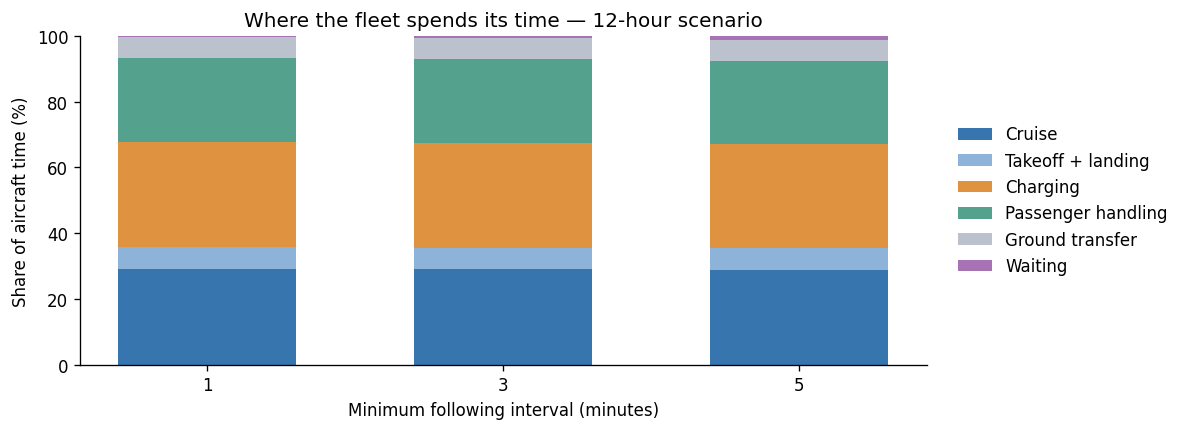

In [6]:
groups = {
    "Cruise": ["cruise"],
    "Takeoff + landing": ["takeoff", "landing"],
    "Charging": ["charging"],
    "Passenger handling": ["unloading", "boarding"],
    "Ground transfer": ["taxi_out", "taxi_in"],
    "Waiting": ["dispatch_wait", "charger_wait"],
}
colours = ["#3675AE", "#8DB4D8", "#DF9341", "#54A28E", "#BBC2CE", "#A773B5"]
fig, ax = plt.subplots(figsize=(10, 3.7))
bottom = [0.0] * len(reports)
for (label, states), colour in zip(groups.items(), colours):
    values = [100 * sum(r["time_fraction"].get(s, 0) for s in states) for r in reports.values()]
    ax.bar([str(h) for h in reports], values, bottom=bottom, label=label, color=colour, width=0.6)
    bottom = [a + b for a, b in zip(bottom, values)]
ax.set(xlabel="Minimum following interval (minutes)", ylabel="Share of aircraft time (%)",
       ylim=(0, 100), title=f"Where the fleet spends its time — {config.horizon_min/60:g}-hour scenario")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout()
fig.savefig("aircraft_time.png", dpi=160, bbox_inches="tight")
plt.show()

### Why do all three baseline throughputs look alike?

With the supplied baseline, each case completes 184 landings in 12 hours: about **15.33 flights/hour**.
This is a finding for these inputs and this dispatch policy, not a claim that headway never matters.

A flight with no waiting takes

$$1+1+9+1+1+4+10+4=31\text{ minutes}$$

from leaving one stand to being ready to leave the next: taxi out, takeoff, cruise, landing,
taxi in, unloading, charging and boarding. A round trip takes 62 minutes.
Eight aircraft therefore give the **long-run fleet upper bound** $8\times60/31\approx15.48$
flights/hour before extra waiting. It is a long-run bound: a short run starts with precharged,
boarded aircraft and need not obey that average. Five-minute following separation allows more
departures than this fleet can sustain, though landing slots can still delay individual departures.

Changing a minimum separation does not impose demand at a rate of $1/h$. There is no passenger
arrival process here. This version measures circulation capacity under continuous readiness to
serve passengers; it cannot yet estimate passenger waiting times or unmet demand.

## 6. Queues, utilisation and the initial transient

There are two waiting states: **dispatch waiting on a stand** and **waiting for a charger**.
An aircraft is not put into a holding queue in the air. Zero charger waiting in the baseline is
expected: each port has as many chargers as stands.

The averages are time-weighted integrals, not averages of arbitrarily spaced samples.
Set `warmup_min` to exclude an initial period. Doing that alone does not prove stationarity;
this deterministic system can settle into a repeating pattern rather than random steady-state queues.

In [7]:
baseline = runs[3]
warmup_min = 120  # Illustrative observation choice, not a proven warm-up requirement.
stats = port_statistics(baseline, warmup_min=warmup_min)
table(["Port", "Occupied stands", "Chargers busy", "Pads busy", "Mean dispatch queue", "Mean charger queue"],
      [[p, f'{s["stand_utilisation"]:.1%}', f'{s["charger_utilisation"]:.1%}',
        f'{s["pad_utilisation"]:.1%}', f'{s["mean_dispatch_queue"]:.3f}',
        f'{s["mean_charger_queue"]:.3f}'] for p, s in stats.items()])
print("Observation begins at", warmup_min, "minutes.")

Observation begins at 120 minutes.


Port,Occupied stands,Chargers busy,Pads busy,Mean dispatch queue,Mean charger queue
A,58.3%,32.4%,25.7%,0.000,0.000
B,58.3%,32.4%,25.7%,0.000,0.000


One-charger throughput: 12.0 flights/hour


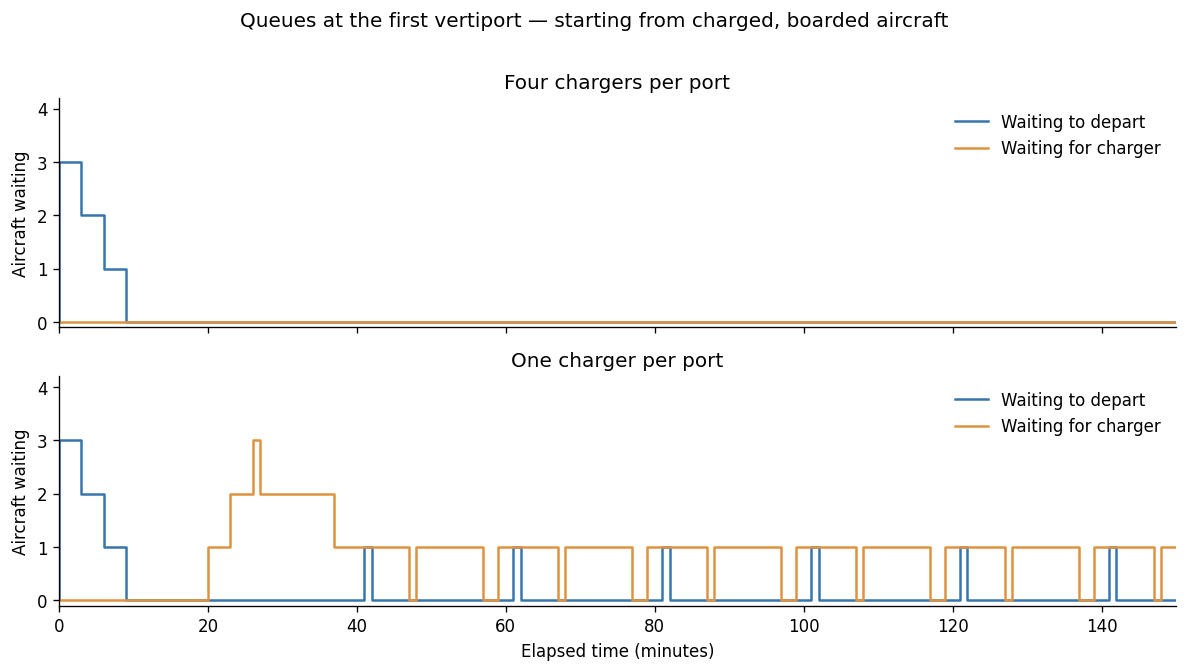

In [8]:
scarce_chargers = Simulation(replace(config, chargers_per_port=1)).run()
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ax, sim, title in zip(axes, [baseline, scarce_chargers],
                         ["Four chargers per port", "One charger per port"]):
    for state, label, colour in [("dispatch_wait", "Waiting to depart", "#3675AE"),
                                  ("charger_wait", "Waiting for charger", "#DF9341")]:
        times, lengths = queue_trace(sim, config.port_names[0], state)
        ax.step(times, lengths, where="post", label=label, color=colour)
    ax.set(ylabel="Aircraft waiting", title=title, ylim=(-0.1, 4.2))
    ax.set_yticks(range(5))
    ax.legend(loc="upper right", frameon=False)
axes[-1].set(xlabel="Elapsed time (minutes)", xlim=(0, 150))
fig.suptitle("Queues at the first vertiport — starting from charged, boarded aircraft", y=1.01)
fig.tight_layout()
fig.savefig("queues.png", dpi=160, bbox_inches="tight")
plt.show()
print("One-charger throughput:", round(summary(scarce_chargers)["flights_per_hour"], 2), "flights/hour")

At the supplied settings, reducing to one charger per port produces a charger queue and
reduces throughput to 12 flights/hour. This comparison checks that charging capacity actually
affects the simulation. Changing `charge_min` is a separate experiment from changing charger count.

## 7. Change the network without rewriting the lifecycle

`routes_km=None` builds a directed ring: A→B→C→A for three ports. It does **not** automatically
mean every pair is connected. Supply a dictionary for other networks. Every port needs an outgoing
route. When a port has several, ready aircraft select them in a repeating order using `itertools.cycle`;
this is a simple routing policy, not passenger demand optimisation.

Initial aircraft are spread across available stands. To specify the initial distribution, set e.g.
`initial_counts={"A": 2, "B": 2, "C": 1}`. This version starts every aircraft on the ground,
so its initial fleet cannot exceed total stand capacity. That is an initial-condition restriction,
not a claim that a real network can never have more aircraft than stands.

In [9]:
three_port_config = replace(config, port_names=("A", "B", "C"), fleet=5, routes_km=None)
three_ports = Simulation(three_port_config).run()
print("Routes:", three_port_config.network())
print("Initial distribution:", three_ports.log.allocations[0][1])
print("Completed flights:", summary(three_ports)["completed_flights"])

# Examples to try later:
# config = replace(config, charge_min=20)
# config = replace(config, port_overrides={"B": {"chargers": 2, "pads": 2}})
# For any change, create a NEW Simulation(config).

Routes: {('A', 'B'): 30, ('B', 'C'): 30, ('C', 'A'): 30}
Initial distribution: {'A': 2, 'B': 2, 'C': 1}
Completed flights: 115


## 8. How the scheduler prevents blocking at full vertiports

If A and B each have four aircraft on four stands, a rule saying “wait until the destination
already has a free stand” would stop everyone. We instead coordinate aircraft that can exchange
stand capacity at the same time.

1. Inspect waiting aircraft in order. Follow their selected routes until a free stand is found,
   or until a closed cycle is formed. For full A and B, that cycle is A→B→A.
2. Give this batch one common time to leave its origin stands. Find departure and landing pad
   windows consistent with existing reservations and each route's minimum following interval.
3. Wait until that transfer time, then commit the stand exchanges together and reserve the pads.
   Release each aircraft's clearance signal.

`allocated` counts **occupied plus promised inbound stands**. It does not mean physical occupancy.
Promises remain until the inbound aircraft lands, uses the stand and later departs. The result is
conservative: a physically empty but promised stand cannot be offered to another aircraft.
Charging and occupied-stand utilisation are measured from actual activity intervals instead.

This policy also has limitations: it chooses one departure per origin in a batch, follows the oldest
request at a full destination, and waits for that batch even if a newer unrelated request could go
earlier. Several pads are supported, but maximum throughput is not guaranteed. These explicit rules
keep the first implementation explainable and give us a baseline for a better scheduler later.

The reservation approach is motivated by [NASA's vertiport scheduling study](https://ntrs.nasa.gov/citations/20205001421).
Our path/cycle policy is our own simplified implementation, not a reproduction of their algorithm.

### How the code relates to the UML

The eight class names follow the agreed architecture; the earlier UML is a design sketch, so some
method and attribute names are shorter in the implementation.

| Class | Responsibility | Read first |
|---|---|---|
| `ScenarioConfig` | Inputs, unit conversion and input checks | Settings at the top |
| `Simulation` | Constructs the network, fleet and processes | `__init__`, `run` |
| `Aircraft` | One repeatedly operating aircraft | `run` |
| `Vertiport` | Stand claims, chargers and pad calendars | `next_pad_slot` |
| `Route` | Directed link, cruise duration and previous departure | Dataclass fields |
| `FlightPlan` | Confirmed operation times and pad choices | Dataclass fields |
| `Scheduler` | Chooses and reserves compatible departures | `choose_batch`, then `plan_batch` |
| `Recorder` | Activity histories, plans and stand allocation snapshots | `intervals` |

`results.py` contains reporting functions, not another simulation framework. `mm1.py` is the
separate mathematical benchmark. `test_model.py` contains verification checks, not operating logic.
Keeping these separate makes `Aircraft.run()` short without hiding resource rules inside it.

## 9. Running longer, or defining an operational failure

`Simulation.run()` has a finite horizon. Call it again with a later absolute time to extend a run.
An endless process cannot be simulated to completion at infinity. Also, a closed fleet has at most
`fleet` aircraft waiting; bounded queues alone do not prove satisfactory operation or exclude deadlock.

Below, an optional experiment stops when a **currently waiting** aircraft has waited at least
10 minutes at a one-minute checkpoint. This threshold is our experiment rule, not an aviation safety
limit. Short breaches between checkpoints may be missed. It detects excessive dispatch/charger
waiting; it does not model battery exhaustion or accidents. `None` means no threshold was detected
before the finite horizon, not proof that no future failure is possible.

In [10]:
stress = Simulation(replace(config, chargers_per_port=1))
failure = run_until_wait_limit(stress, wait_limit_min=10, check_every_min=1)
print(failure)

# Extend a normal run if needed:
# baseline.run(until_min=7 * 24 * 60)
# print(summary(baseline, warmup_min=24 * 60))

{'reason': 'charger_wait', 'aircraft': 'A3', 'port': 'B', 'detected_at_min': 33.0, 'wait_min': 9.999999999999996}


## 10. The separate M/M/1 benchmark

The M/M/1 queue has Poisson arrivals, exponential service durations and one server.
Let $N(t)$ include customers waiting **and in service**, and $p_n(t)=P(N(t)=n)$.
The boundary equation is

$$p'_0(t)=-\lambda p_0(t)+\mu p_1(t).$$

The negative arrival term matters: an arrival leaves state zero. For $n\ge1$,
$p'_n=\lambda p_{n-1}-(\lambda+\mu)p_n+\mu p_{n+1}$.
In equilibrium the derivatives vanish. Normalising gives
$p_n=(1-\rho)\rho^n$, where $\rho=\lambda/\mu<1$.
Then

$$L=\frac{\rho}{1-\rho},\quad L_q=L-\rho=\frac{\rho^2}{1-\rho},\quad
W_q=\frac{L_q}{\lambda}=\frac{\lambda}{\mu(\mu-\lambda)}.$$

For $\lambda=2/3$ and $\mu=1$ per minute, $W_q=2$ minutes and $L_q=4/3$ customers.
[Constantin (2011), §§2.3–2.4](https://www.math.uchicago.edu/~may/VIGRE/VIGRE2011/REUPapers/Constantin.pdf)
provides the theoretical backbone. Multiple transitions in a small interval have probability
$o(\Delta t)$; they are not literally impossible.

The aircraft network has fixed durations, a finite circulating fleet and linked resources. Its
queue length alone is not an M/M/1 continuous-time Markov chain. We use the benchmark to check the
queueing implementation, not to claim its waiting-time formula solves the whole simulator.

In [11]:
benchmark = mm1(arrival_rate=2/3, service_rate=1, horizon_min=100000,
                warmup_min=10000, time_scale_min=config.time_scale_min, seed=42)
table(["Quantity", "Value"], [
    ["Intensity rho", f'{benchmark["rho"]:.3f}'],
    ["Theoretical Wq", f'{benchmark["Wq_theory_min"]:.3f} min'],
    ["Simulated Wq", f'{benchmark["Wq_simulated_min"]:.3f} min'],
    ["Post-warm-up arrivals", benchmark["arrivals_measured"]],
])

Quantity,Value
Intensity rho,0.667
Theoretical Wq,2.000 min
Simulated Wq,2.066 min
Post-warm-up arrivals,59893


This benchmark starts empty, discards arrivals before warm-up and drains the finite arrival
cohort to measure complete waiting times. Separate seeded random streams generate arrivals and
service times. One stochastic run is a numerical check, not a proof or a confidence interval;
repeat with different seeds before making statistical claims.

## 11. What has been verified, and how to explain it

The supplied tests check a hand-calculated 31-minute journey, full-port circulation, three ports,
five aircraft, unequal route distances, different capacities, fleets on networks of up to six ports,
pad overlap, charger/stand limits, following intervals and agreement between booked slots and actual
aircraft transitions. They also check partial activities at the run cutoff, changing reference units,
extending a run, the optional wait stop and the M/M/1 benchmark. Run them with
`python -m unittest -v test_model` from this folder.

For your professor, explain these points in order:

1. **Question:** how do fleet size, turnaround and infrastructure limit circulation?
2. **Assumptions:** constant speed/durations, fixed fleet, no airborne holding, no passenger demand model.
3. **Units:** physical input → dimensionless simulation → physical output; scaling changes no prediction.
4. **Mechanism:** describe one aircraft's cycle, then why full ports need coordinated departures.
5. **Evidence:** compare the hand calculation, the capacity checks and the three headway results.
6. **Theory boundary:** M/M/1 is a validated teaching benchmark; our full network is a different model.
7. **Experiments:** the next section tests sensitivity to charging and fleet size. Improved scheduling,
   stochastic turnaround, energy, demand, airspace intersections and regulations remain future extensions.

The current results are scenario predictions, not evidence of real-world operational safety or maximum
network capacity. The core is deliberately small enough to read, while keeping the rules that matter.

<a id="step6"></a>
## 12. Step 6 — validation and experiments

The core simulator is unchanged. We have added measurements to the M/M/1 benchmark and a separate
`experiments.py` file. There are **60 stochastic M/M/1 runs, 44 aircraft sensitivity cases and two
30-day aircraft runs**. All 20 automated tests pass. Every aircraft experiment also undergoes checks
of recorded pad slots, following intervals, resource capacities, stand claims and aircraft time.

These are three different kinds of evidence:

| Check | What it tells us | What it cannot establish |
|---|---|---|
| Hand calculations and resource checks | The implementation respects the stated timing/capacity rules in the tested cases. | Every possible configuration is correct. |
| M/M/1 comparison with theory | Independent stochastic simulations reproduce known queueing quantities. | The whole eVTOL network is M/M/1. |
| Sensitivity and longer runs | Which assumptions and resources limit this model's achieved throughput. | Real-aircraft performance, certified operations or optimal scheduling. |

The aircraft model is deterministic. We vary inputs and horizons rather than inventing random seeds
or confidence intervals for identical runs. The M/M/1 benchmark is stochastic, so replication is useful.

In [12]:
import json
from pathlib import Path
from statistics import mean
from hashlib import sha256

# Saved results are for the published baseline, independent of exploratory edits above.
# Set True to rerun the experiment grid; this takes longer than the introductory cells.
RECOMPUTE_STEP_6 = False
if RECOMPUTE_STEP_6:
    from experiments import run_experiments
    study = run_experiments()  # Experiment settings and grid are in experiments.py.
    Path("experiment_results.json").write_text(json.dumps(study, indent=2, allow_nan=False))
else:
    study = json.loads(Path("experiment_results.json").read_text())

print("M/M/1 runs:", len(study["mm1_runs"]))
print("Aircraft sensitivity cases:", len(study["sensitivity"]))
print("Long-run cases:", len(study["long_runs"]))
print("All aircraft audits passed:", all(r["audit"]["passed"] for r in
                                         study["sensitivity"] + study["long_runs"]))
source_matches = all(sha256(Path(name).read_bytes()).hexdigest() == digest
                     for name, digest in study["source_hashes"].items())
print("Saved experiments match current source files:", source_matches)
if not source_matches:
    print("Source files changed: recompute step 6 before interpreting these as current results.")

M/M/1 runs: 60
Aircraft sensitivity cases: 44
Long-run cases: 2
All aircraft audits passed: True
Saved experiments match current source files: True


## 13. Does the M/M/1 implementation agree with theory?

We fix $\mu=1$ service/minute and use $\rho=0.25,\;2/3,\;0.9$. Each intensity has 20 replications,
each with a 100,000-minute arrival horizon and a 10,000-minute warm-up. Every run uses distinct seeded
arrival and service streams. Individual customer waits within a run are correlated; **each whole-run
mean is one observation** when constructing the confidence interval.

The interval is $\bar x\pm t_{0.975,19}s/\sqrt{20}$. This is a Student-t interval across replication
means, relying on their approximate normality after long runs. SciPy supplies the t critical value.
See [NIST's confidence-interval formula](https://www.itl.nist.gov/div898/handbook/eda/section3/eda352.htm).
The intervals are pointwise 95% intervals, not a simultaneous 95% guarantee for every reported metric.

We measure $W_q$ from completed customer waits, while $L_q$ and busy fraction come independently from
the time spent in each population state. Specifically, $L_q$ integrates $\max(N(t)-1,0)$ over the
observation window. We do not obtain simulated $L_q$ by multiplying simulated $W_q$ by $\lambda$.
The wait cohort is drained after arrivals stop; state integrals stop at the horizon. Small finite-window
differences between these estimators are expected.

In [13]:
wait_results = [r for r in study["mm1_intervals"] if r["metric"] == "Wq_simulated_min"]
table(["Intensity rho", "Theory Wq (min)", "Mean simulated Wq (min)", "95% interval", "Relative error"],
      [[f'{r["rho"]:.3f}', f'{r["theory"]:.3f}', f'{r["mean"]:.3f}',
        f'[{r["lower"]:.3f}, {r["upper"]:.3f}]', f'{r["relative_error"]:+.2%}'] for r in wait_results])
covered = sum(r["lower"] <= r["theory"] <= r["upper"] for r in study["mm1_intervals"])
print(f"Theory falls within {covered} of {len(study['mm1_intervals'])} pointwise intervals.")

Theory falls within 9 of 9 pointwise intervals.


Intensity rho,Theory Wq (min),Mean simulated Wq (min),95% interval,Relative error
0.250,0.333,0.332,"[0.328, 0.335]",-0.53%
0.667,2.000,2.007,"[1.985, 2.030]",+0.37%
0.900,9.000,8.864,"[8.683, 9.045]",-1.51%


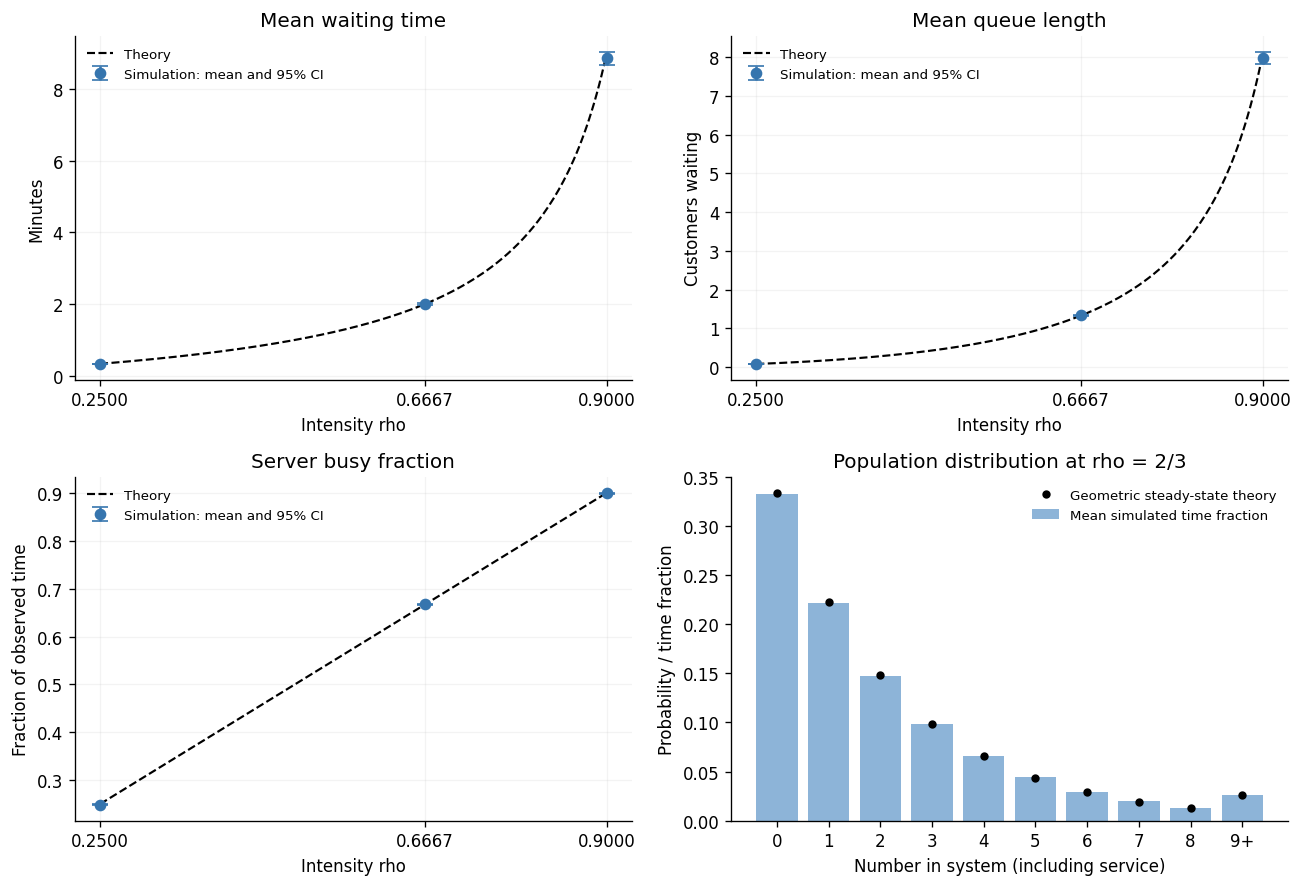

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, metric, title, ylabel in zip(axes.flat, ["Wq_simulated_min", "Lq_simulated", "busy_fraction"],
                                   ["Mean waiting time", "Mean queue length", "Server busy fraction"],
                                   ["Minutes", "Customers waiting", "Fraction of observed time"]):
    rows = [r for r in study["mm1_intervals"] if r["metric"] == metric]
    x = [r["rho"] for r in rows]
    grid = [min(x) + (max(x)-min(x))*i/200 for i in range(201)]
    theoretical = ([r/(1-r) for r in grid] if metric == "Wq_simulated_min" else
                   [r*r/(1-r) for r in grid] if metric == "Lq_simulated" else grid)
    ax.plot(grid, theoretical, "k--", label="Theory", linewidth=1.3)
    ax.errorbar(x, [r["mean"] for r in rows],
                yerr=[[r["mean"]-r["lower"] for r in rows], [r["upper"]-r["mean"] for r in rows]],
                fmt="o", color="#3675AE", capsize=5, label="Simulation: mean and 95% CI")
    ax.set(xlabel="Intensity rho", ylabel=ylabel, title=title, xticks=x)
    ax.grid(alpha=0.15)
    ax.legend(fontsize=8, frameon=False)

ax = axes[1, 1]
rho = 2/3
prob_runs = [r["state_probabilities"] for r in study["mm1_runs"] if abs(r["rho"]-rho) < 1e-8]
observed = [mean(p.get(str(n), p.get(n, 0)) for p in prob_runs) for n in range(9)]
observed.append(mean(sum(v for k, v in p.items() if int(k) >= 9) for p in prob_runs))
theory = [(1-rho)*rho**n for n in range(9)] + [rho**9]
ax.bar(range(10), observed, color="#8DB4D8", label="Mean simulated time fraction")
ax.plot(range(10), theory, "ko", markersize=4, label="Geometric steady-state theory")
ax.set(xticks=range(10), xticklabels=[str(i) for i in range(9)] + ["9+"],
       xlabel="Number in system (including service)", ylabel="Probability / time fraction",
       title="Population distribution at rho = 2/3")
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig("step6_mm1.png", dpi=160, bbox_inches="tight")
plt.show()

At intensity 2/3, the mean waiting time is **2.007 minutes** versus the theoretical **2.000**;
the interval is **1.985–2.030 minutes**. All nine intervals for waiting time, queue length and busy
fraction contain their theoretical values. At intensity 0.9 the mean wait is about 8.864 minutes
versus 9.000; its uncertainty is larger. Agreement supports the benchmark implementation and its
measurement logic. It does not prove the full aircraft model valid for actual operations.

## 14. What limits aircraft throughput?

For each aircraft sensitivity case we run **seven days**, exclude the **first day**, and measure the
following six days. Durations, starting conditions and the scheduler remain deterministic. The grid is
exploratory; the 5–30-minute charge times and 10-minute headway are hypothetical stress settings, not
new measured specifications. The original 1-, 3- and 5-minute headways are included.

For symmetric A/B operations, useful necessary **long-run** upper bounds on both-direction throughput
in flights/hour are

$$X\le\min\left(\frac{60N}{21+c},\frac{120C}{c},
\frac{120P}{t_{TO}+t_L},\frac{120S}{8+c},\frac{120}{h}\right).$$

Here $N$ is total fleet, $C,P,S$ are chargers, pads and stands **per port**; $c,h$ and pad durations
are in minutes. The 21 minutes are the baseline non-charging part of a flight cycle; the eight minutes
are unloading plus boarding. In general, use the actual cycle durations rather than those constants.
These bounds count available aircraft/resource time. They do not guarantee a feasible timetable;
reservations and phase conflicts can make achieved throughput lower. A finite observation window may
also sit slightly above a long-run bound because of flights crossing its endpoints.

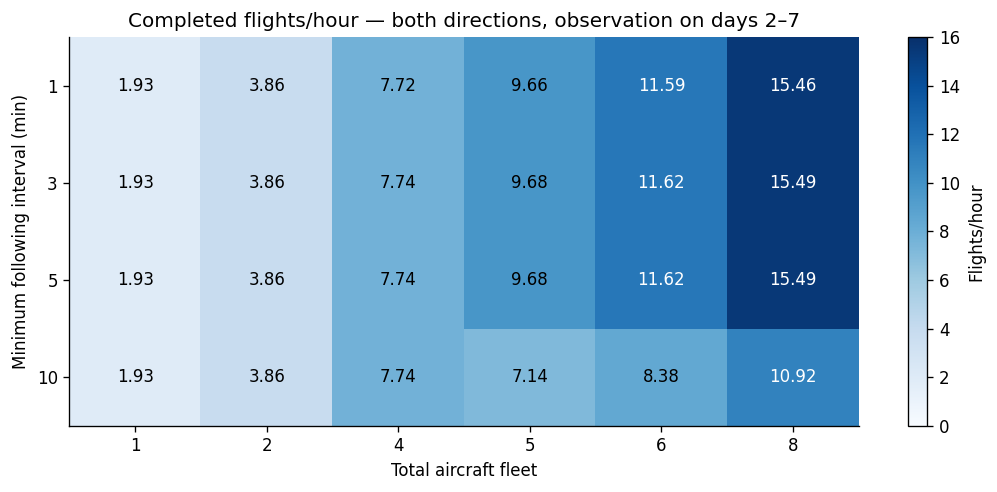

In [15]:
fleet_rows = [r for r in study["sensitivity"] if r["group"] == "fleet_headway"]
fleets = sorted({r["fleet"] for r in fleet_rows})
headways = sorted({r["headway_min"] for r in fleet_rows})
lookup = {(r["fleet"], r["headway_min"]): r["flights_per_hour"] for r in fleet_rows}
values = [[lookup[n, h] for n in fleets] for h in headways]
fig, ax = plt.subplots(figsize=(9, 4.2))
im = ax.imshow(values, cmap="Blues", vmin=0, vmax=16, aspect="auto")
for i, h in enumerate(headways):
    for j, n in enumerate(fleets):
        value = values[i][j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 10 else "black")
ax.set(xticks=range(len(fleets)), xticklabels=fleets, yticks=range(len(headways)), yticklabels=headways,
       xlabel="Total aircraft fleet", ylabel="Minimum following interval (min)",
       title="Completed flights/hour — both directions, observation on days 2–7")
fig.colorbar(im, ax=ax, label="Flights/hour")
fig.tight_layout()
fig.savefig("step6_fleet_headway.png", dpi=160, bbox_inches="tight")
plt.show()

For the original headways, throughput increases approximately in proportion to fleet size.
With eight aircraft it is about **15.5 flights/hour**. Differences of a few hundredths between the
1-, 3- and 5-minute cases mostly reflect where a finite observation window cuts the repeating cycle.

The 10-minute stress case reveals a scheduling effect. With eight aircraft and one pad at each port,
throughput is **10.92 flights/hour**, below the headway-only bound of 12. The first simultaneous pair
uses departure slots [1,2] minutes and landing slots [11,12]. A departure ten minutes after the first
would need [11,12] too; the scheduler delays it. In this case the repeating takeoff spacing is 11 minutes.
Two pads per port remove that conflict and produce 12 flights/hour.

There is also a non-monotonic result: at the 10-minute headway, five aircraft achieve about 7.14
flights/hour, whereas four achieve 7.74. Adding a second pad raises the five-aircraft result to only 7.50.
This exposes sensitivity to dispatch order and coordinated departures in our conservative policy.
It is **not** a general claim that more aircraft reduce achievable network capacity. An optimised
scheduler could choose to leave an extra aircraft idle. We have retained this finding rather than
tuning the policy to make every curve increase.

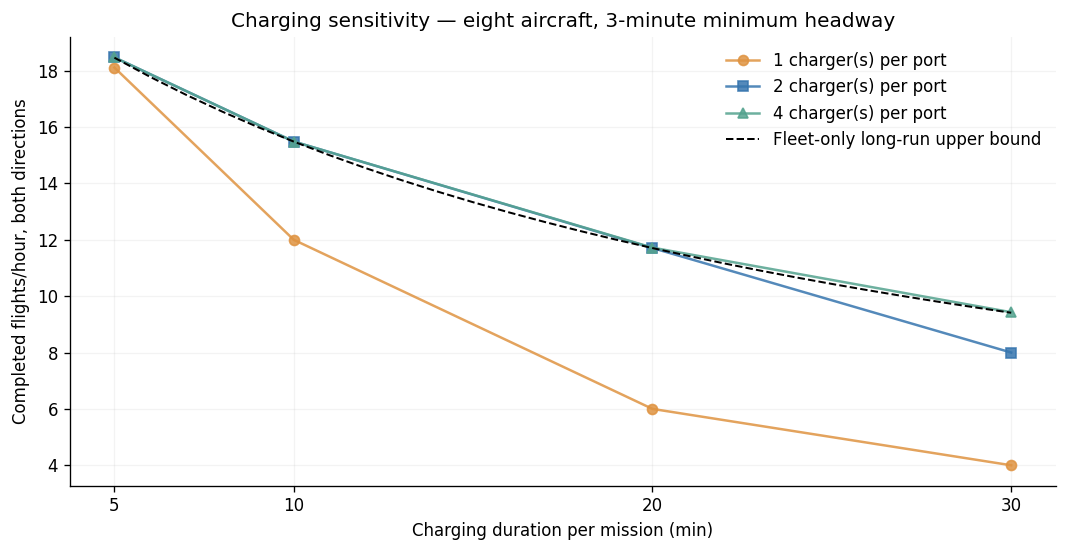

Chargers/port,Flights/hour,Charger utilisation at A,Mean charger queue at A
1,12.00,100.0%,0.85
2,15.49,64.5%,0.00
4,15.49,32.3%,0.00


In [16]:
charge_rows = [r for r in study["sensitivity"] if r["group"] == "charge_chargers"]
fig, ax = plt.subplots(figsize=(9, 4.7))
for chargers, colour, marker in [(1, "#DF9341", "o"), (2, "#3675AE", "s"), (4, "#54A28E", "^")]:
    rows = sorted([r for r in charge_rows if r["chargers_per_port"] == chargers], key=lambda r:r["charge_min"])
    ax.plot([r["charge_min"] for r in rows], [r["flights_per_hour"] for r in rows],
            marker=marker, color=colour, label=f"{chargers} charger(s) per port", alpha=0.85)
times = list(range(5, 31))
ax.plot(times, [480/(21+c) for c in times], "k--", linewidth=1.2, label="Fleet-only long-run upper bound")
ax.set(xlabel="Charging duration per mission (min)", ylabel="Completed flights/hour, both directions",
       title="Charging sensitivity — eight aircraft, 3-minute minimum headway", xticks=[5, 10, 20, 30])
ax.grid(alpha=0.15)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("step6_charging.png", dpi=160, bbox_inches="tight")
plt.show()

rows = [r for r in charge_rows if r["charge_min"] == 10]
table(["Chargers/port", "Flights/hour", "Charger utilisation at A", "Mean charger queue at A"],
      [[r["chargers_per_port"], f'{r["flights_per_hour"]:.2f}',
        f'{r["ports"]["A"]["charger_utilisation"]:.1%}',
        f'{r["ports"]["A"]["mean_charger_queue"]:.2f}'] for r in rows])

At ten-minute charging, one charger per port limits throughput to **12 flights/hour**, matching
the available charging capacity. Two and four chargers both give approximately **15.49 flights/hour**.
Two therefore suffice for the sustained throughput of this deterministic scenario. They offer less spare
capacity than four; this is not yet a recommendation for real infrastructure with variable service,
failures or uncertain demand.

With four chargers, increasing charging duration from 10 to 20 minutes reduces throughput from about
15.49 to 11.72 flights/hour; at 30 minutes it is about 9.43. Charging duration remains important even
when nobody queues for a charger: it keeps each aircraft unavailable for another flight.

Adding a second pad per port has no throughput benefit at the baseline 3-minute headway. With five
aircraft, the tested two-port route and three-port directed ring both give about 9.68 flights/hour;
the three-port case adds an equal-distance destination, not extra aircraft. Starting the two-port,
five-aircraft case with a 3/2 rather than 4/1 distribution also gives the same six-day measured rate.
These are results for these cases, not universal statements about topology or initial conditions.

## 15. Initial conditions, observation windows and long runs

We extend the same simulations to 12, 24, 72, 168 and 720 hours. At each horizon we inspect cumulative
results and, where possible, remove the first 2, 12 or 24 hours. We also look at separate 24-hour bins.
This distinguishes the starting condition from a repeating schedule and from an arbitrary bin boundary.

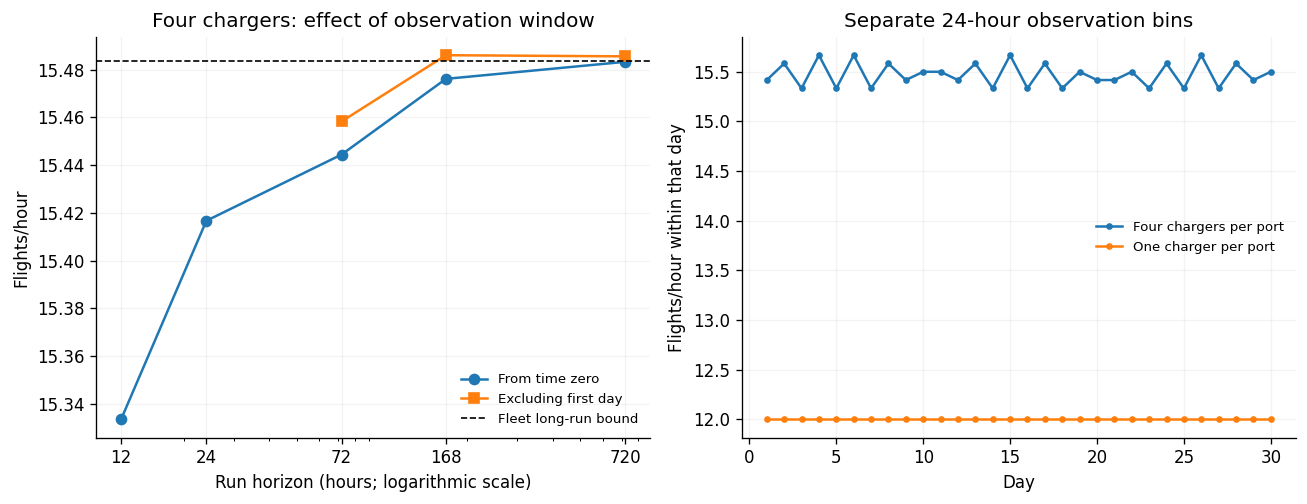

Run horizon (hours),Observation starts (hours),Flights/hour
12,0,15.33333
24,0,15.41667
72,0,15.44444
72,24,15.45833
168,0,15.47619
168,24,15.48611
720,0,15.48333
720,24,15.48563


In [17]:
four = next(r for r in study["long_runs"] if r["chargers_per_port"] == 4)
one = next(r for r in study["long_runs"] if r["chargers_per_port"] == 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for start, label, marker in [(0, "From time zero", "o"), (1440, "Excluding first day", "s")]:
    rows = [r for r in four["snapshots"] if r["window_start_min"] == start]
    axes[0].plot([r["window_end_min"]/60 for r in rows], [r["flights_per_hour"] for r in rows],
                 marker=marker, label=label)
axes[0].axhline(480/31, linestyle="--", color="black", linewidth=1, label="Fleet long-run bound")
axes[0].set(xscale="log", xlabel="Run horizon (hours; logarithmic scale)", ylabel="Flights/hour",
            title="Four chargers: effect of observation window")
axes[0].set_xticks([12, 24, 72, 168, 720])
axes[0].set_xticklabels([12, 24, 72, 168, 720])
axes[0].legend(fontsize=8, frameon=False)
for case, label in [(four, "Four chargers per port"), (one, "One charger per port")]:
    axes[1].plot([r["day"] for r in case["daily"]], [r["flights_per_hour"] for r in case["daily"]],
                 marker=".", label=label)
axes[1].set(xlabel="Day", ylabel="Flights/hour within that day", title="Separate 24-hour observation bins")
axes[1].legend(fontsize=8, frameon=False)
for ax in axes:
    ax.grid(alpha=0.15)
fig.tight_layout()
fig.savefig("step6_long_runs.png", dpi=160, bbox_inches="tight")
plt.show()

rows = [r for r in four["snapshots"] if r["window_start_min"] in (0, 1440)]
table(["Run horizon (hours)", "Observation starts (hours)", "Flights/hour"],
      [[f'{r["window_end_min"]/60:.0f}', f'{r["window_start_min"]/60:.0f}',
        f'{r["flights_per_hour"]:.5f}'] for r in rows])

The four-charger rate measured from startup changes from **15.333 flights/hour at 12 hours**
to **15.483 at 30 days**, close to $480/31=15.484$. Excluding the first day gives **15.486** over the
remaining 29 days. That tiny excess over the long-run bound is a finite-window endpoint effect.
Individual daily bins vary approximately between 15.33 and 15.67 because the operating cycle does not
divide evenly into 24 hours. The one-charger case gives 12 flights/hour throughout these checkpoints.

Discarding a warm-up period does not guarantee a closer estimate in every finite window. In this
deterministic model, a repeating pattern can persist under time-invariant parameters. That is different
from proving a stationary probability distribution. The 30-day runs continue making progress and pass
all recorded resource checks, but cannot prove indefinite operation or validate unmodelled battery limits.

In the baseline long run, each no-wait cycle allocates about $9/31=29.0\%$ of aircraft time to cruise
and $10/31=32.3\%$ to charging. Takeoff and landing are recorded separately. This provides a direct
answer to the flying-versus-charging question without silently treating all other time as flying.

## 16. Conclusions 

1. **The implementation passes the checks used here.** All 20 tests pass, and all 44 sensitivity cases
   plus both 30-day cases pass the complete recorded-flight/resource audits.
2. **The mathematical benchmark agrees with theory.** Independent M/M/1 estimates for waiting time,
   queue length and utilisation agree within the reported pointwise intervals at three intensities.
3. **Fleet turnaround limits the baseline.** Eight aircraft sustain roughly 15.5 flights/hour under
   the chosen assumptions. The original 1/3/5-minute headways make little sustained difference.
4. **Charging time and charging capacity are distinct constraints.** One ten-minute charger per port
   caps throughput at 12 flights/hour. Two can sustain baseline circulation; longer charge durations
   reduce fleet availability even when a charger queue is absent.
5. **Scheduling matters beyond simple rate bounds.** The 10-minute stress cases expose pad-slot
   conflicts and a conservative dispatch policy that can perform worse after adding an aircraft.
6. **Longer observation reduces some starting/endpoint effects.** It does not prove stationarity,
   indefinite feasibility or the accuracy of the physical assumptions.


